# Example of D2002 computation

In [2]:
%load_ext autoreload
%autoreload 1
%aimport rbamlib

import numpy as np
from rbamlib.models.ne import D2002
import matplotlib.pyplot as plt

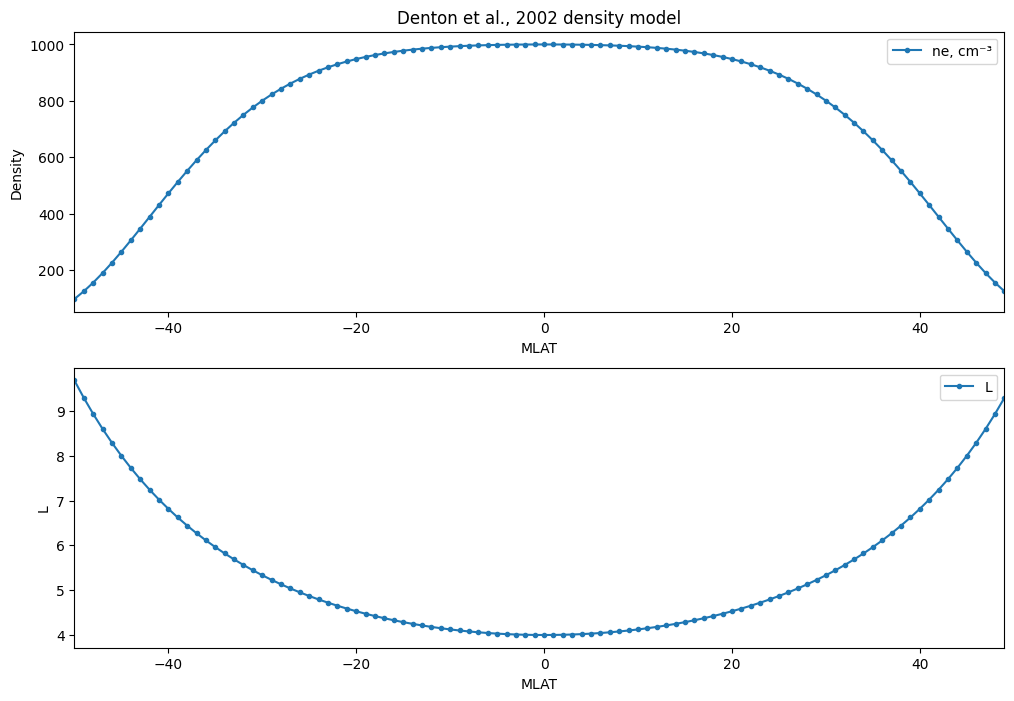

In [31]:
# Define the range of L, r and ne_eq value
r = 4 
mlat = np.arange(-50, 51, 1) 
L = r / np.cos(np.deg2rad(mlat)) ** 2  # in dipole
ne_eq = 1000
ne = D2002(r=r, L=L, ne_eq=ne_eq)


# Plot the results in matplotlib
fig, ax = plt.subplots(2,1, figsize=(12, 8))  # single Axes on a Figure

ax[1].plot(mlat, L, label="L", marker='.')
ax[0].plot(mlat, ne, label="ne, cm⁻³", marker='.')

ax[0].set_title("Denton et al., 2002 density model")
ax[0].set_xlabel("MLAT")
ax[0].set_ylabel("Density")
ax[0].legend(loc='upper right')

ax[1].set_xlabel("MLAT")
ax[1].set_ylabel("L")
ax[1].legend(loc='upper right')

ax[0].set(xlim=(mlat[0], mlat[-1]))
ax[1].set(xlim=(mlat[0], mlat[-1]))

plt.show()

Example from Denton et al. (2006), Figure 1(a), top panel. 

Denton, R. E., K. Takahashi, I. A. Galkin, P. A. Nsumei, X. Huang, B. W. Reinisch, R. R. Anderson, M. K. Sleeper, and W. J. Hughes (2006), Distribution of density along magnetospheric field lines, J. Geophys. Res., 111, A04213, doi:10.1029/
2005JA011414.

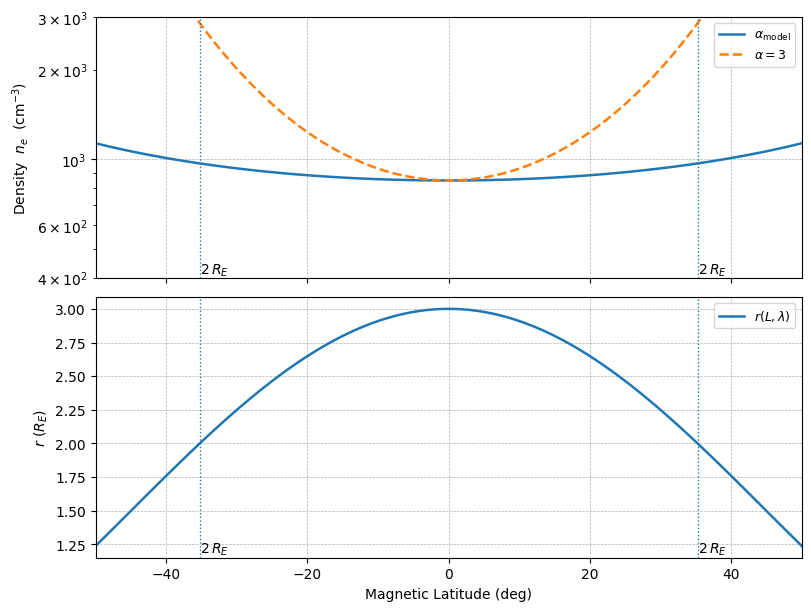

In [69]:
# Inputs (keep these on separate lines for clarity)
L = 3.0
ne_eq = 849.0

# Latitude grid and field-line distance
mlat = np.arange(-50, 51, 1)                     # degrees
r = L * np.cos(np.deg2rad(mlat))**2              # r/Re along the field line

# Densities
ne_model = D2002(r=r, L=L, ne_eq=ne_eq)          # α from Denton model
ne_a3    = D2002(r=r, L=L, ne_eq=ne_eq, alpha=3) # fixed α = 3

# Latitude where r = 2 Re (vertical guides)
lam_2Re = np.degrees(np.arccos(np.sqrt(2.0 / L)))

# Figure and axes
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True, constrained_layout=True)

# --- Plot data ---
# Top: density
axs[0].plot(mlat, ne_model, '-',  lw=1.8, label=r'$\alpha_{\rm model}$')
axs[0].plot(mlat, ne_a3,    '--', lw=1.8, label=r'$\alpha=3$')

# Bottom: r vs latitude
axs[1].plot(mlat, r, '-', lw=1.8, label=r'$r(L,\lambda)$')

# Settings
axs[0].set_yscale("log")
axs[0].set_ylim(400, 3000)

# Shared x-axis settings
axs[-1].set_xlabel("Magnetic Latitude (deg)", fontsize=10)
axs[0].set_xlim(mlat[0], mlat[-1])

# Common per-axis formatting via zip (only what truly applies to both)
ylabels = ["Density  $n_e$  (cm$^{-3}$)", r"$r\ (R_E)$"]
for ax, ylab in zip(axs, ylabels):
    ax.set_ylabel(ylab, fontsize=10)
    ax.grid(True, linestyle="--", linewidth=0.5)
    ax.legend(loc='upper right', fontsize=9)
    
    # Vertical guide lines on both panels  
    for v in (-lam_2Re, lam_2Re):
        ax.axvline(v, ls=':', lw=1)
        ax.text(v, ax.get_ylim()[0], r'$2\,R_E$', ha='left', va='bottom')

plt.show()